In [281]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv
/kaggle/input/datasets/anuragsai99/churn-dataset/sample_submission.csv
/kaggle/input/datasets/anuragsai99/churn-dataset/train.csv
/kaggle/input/datasets/anuragsai99/churn-dataset/test.csv


In [282]:
kagglehub.competition_download('playground-series-s6e3')

'/kaggle/input/competitions/playground-series-s6e3'

In [283]:
df_test=pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")

In [284]:
df=pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")

In [285]:
df.sample(5)
df_test.sample(5)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
44009,638203,Female,0,No,No,29,Yes,Yes,DSL,No,No,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,71.30,1882.00
250623,844817,Female,0,Yes,Yes,66,Yes,Yes,DSL,No,No,No,No,Yes,Yes,Two year,Yes,Credit card (automatic),67.85,4103.35
254226,848420,Male,0,Yes,Yes,68,Yes,No,DSL,Yes,Yes,Yes,Yes,No,Yes,Two year,Yes,Credit card (automatic),74.55,5154.50
21789,615983,Male,0,Yes,Yes,48,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),20.70,917.15
23744,617938,Female,1,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),116.55,8456.75


In [307]:
def apply_mappings(data):
    mappings = {
        'gender': {'Male':1,'Female':0},
        'PaymentMethod': {
            'Electronic check':1,
            'Mailed check':0,
            'Credit card (automatic)':0,
            'Bank transfer (automatic)':0
        },
        'Contract':{'One year':1, 'Two year':2, 'Month-to-month':0},
        'InternetService':{'DSL':0, 'Fiber optic':1, 'No':0}
    }
    
    for col, mapping in mappings.items():
        data[col] = data[col].replace(mapping)
    
    return data

In [308]:
df = apply_mappings(df)
df_test = apply_mappings(df_test)

In [310]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
cols=['tenure','MonthlyCharges','TotalCharges']
df[cols]=ss.fit_transform(df[cols])
df_test[cols]=ss.fit_transform(df_test[cols])

In [326]:
mapping = {
    'Yes': 1,
    'No': 0,
    'No internet service': 0,
    'No phone service': 0
}

yes_no_cols = [
    col for col in df_test.columns
    if df_test[col].dtype == 'object' and set(df[col].dropna().unique()).issubset(mapping.keys())
]

for col in yes_no_cols:
    df_tets[col] = df_test[col].replace(mapping)
    
    if col in df_test.columns:
        df_test[col] = df_test[col].replace(mapping)

In [327]:
df_test.isnull().sum()

id                       0
gender                   0
SeniorCitizen            0
Partner             254655
Dependents          254655
tenure                   0
PhoneService        254655
MultipleLines       254655
InternetService          0
OnlineSecurity      254655
OnlineBackup        254655
DeviceProtection    254655
TechSupport         254655
StreamingTV         254655
StreamingMovies     254655
Contract                 0
PaperlessBilling    254655
PaymentMethod            0
MonthlyCharges           0
TotalCharges             0
dtype: int64

<Axes: xlabel='InternetService', ylabel='count'>

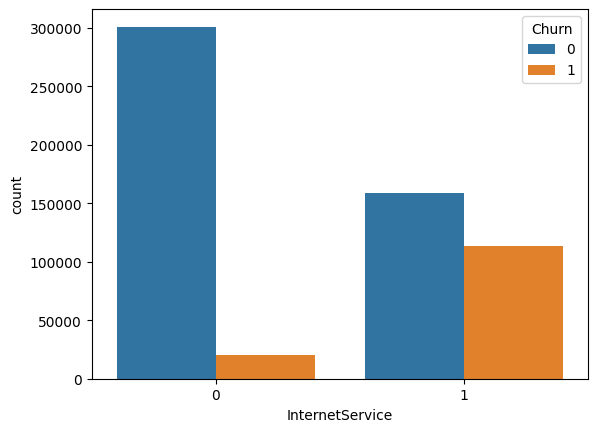

In [258]:
import seaborn as sns

sns.countplot(x='InternetService', hue='Churn', data=df)

<Axes: xlabel='PaymentMethod', ylabel='count'>

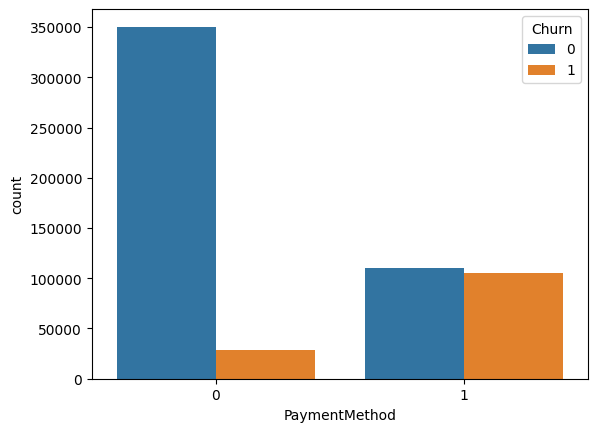

In [259]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

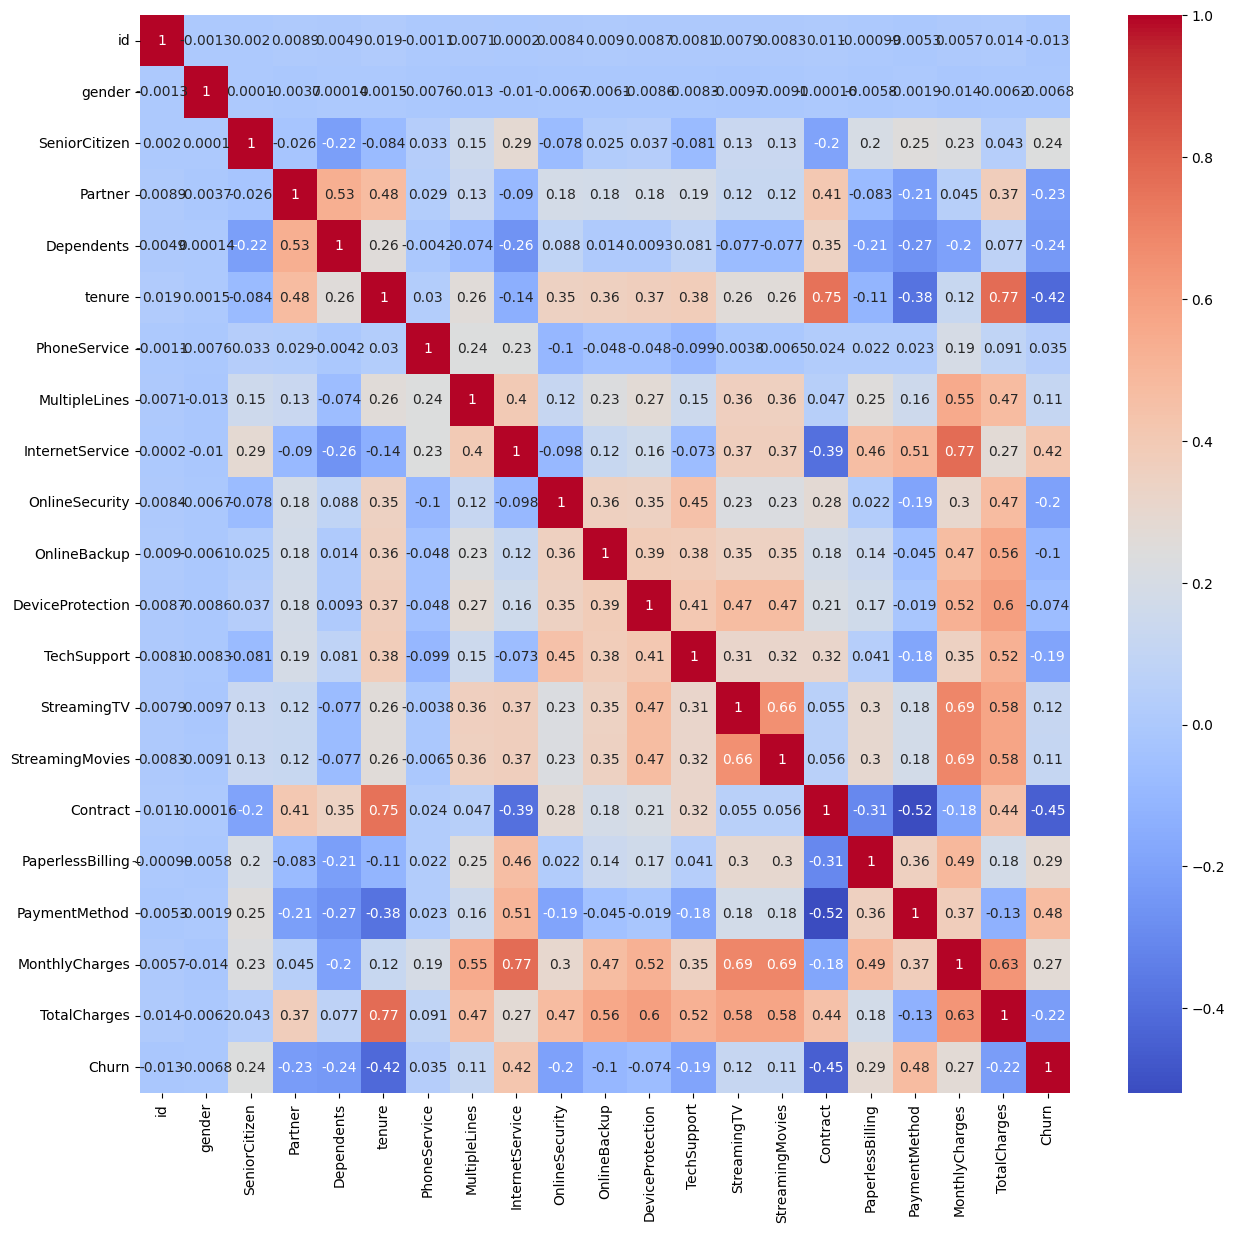

In [260]:
plt.figure(figsize=(15,14))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [261]:
df.head(5)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,0,1,1,-0.302342,1,0,0,1,...,1,1,0,0,1,1,0,-0.185604,-0.357076,0
1,1,1,0,1,1,0.854793,1,0,0,1,...,0,1,1,0,2,0,0,0.116964,0.545399,0
2,2,1,0,1,0,0.854793,1,1,1,0,...,0,0,1,1,0,1,1,1.111575,1.421875,0
3,3,0,0,0,0,-1.419575,1,0,1,0,...,0,0,0,0,0,1,1,0.123402,-1.029637,1
4,4,0,0,0,0,-1.419575,1,0,1,0,...,0,0,0,0,0,1,1,0.147543,-1.029743,1


In [262]:
from sklearn.model_selection import train_test_split
x_train,xtest,ytrain,ytest=train_test_split(df.drop(columns=['Churn']),df['Churn'],test_size=0.2,random_state=3)


# I don't want to make a pipeline of the models so i am using them separately and comparing

In [263]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=10000, solver='lbfgs')
# lr.fit(x_train,ytrain)
# from sklearn.tree import DecisionTreeClassifier
# dt=DecisionTreeClassifier(max_depth=10)
# dt.fit(x_train,ytrain)
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42)
rf.fit(x_train,ytrain)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [264]:
ypred=rf.predict(xtest)

In [246]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.8580768939489561

In [278]:
test_ans=rf.predict(df_test)


In [279]:

submission = pd.DataFrame({"Churn": test_ans})

# Save to CSV
submission.to_csv("submission.csv", index=False)

<Axes: >

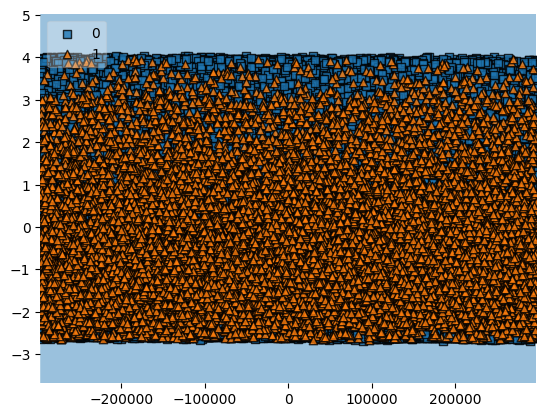

In [247]:
from sklearn.decomposition import PCA
from mlxtend.plotting import plot_decision_regions
ynum=ytest.to_numpy()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(xtest)

lr.fit(X_pca, ytest)
plot_decision_regions(X_pca, ynum, clf=lr, legend=2)